## Requirements

In [22]:
import os
import glob
import cv2
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

## 1-Pytorch Dataset Template

In [3]:
class IndustrialDataset(Dataset):
    def __init__(self, image_dir, label_dir, image_size=640):

        self.image_dir = image_dir
        self.label_dir = label_dir
        self.image_size = image_size
        self.image_files = sorted(glob.glob(os.path.join(image_dir, "*")))

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):

        img_path = self.image_files[idx]

        name = os.path.splitext(os.path.basename(img_path))[0]
        label_path = os.path.join(self.label_dir, name + ".txt")


        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        h, w = image.shape[:2]

        image = cv2.resize(image, (self.image_size, self.image_size))
        image = image.astype(np.float32) / 255.0
        image = image.transpose(2, 0, 1)
        image = torch.tensor(image, dtype=torch.float32)


        with open(label_path) as f:
            line = f.readline().strip()

        nums = list(map(float, line.split()))
        cls = int(nums[0])
        bbox = torch.tensor(nums[1:5], dtype=torch.float32)
        kp = nums[5:]
        keypoints = []

        for i in range(0, len(kp), 3):
            x = kp[i]
            y = kp[i + 1]
            v = kp[i + 2]

            keypoints.append([x, y, v])

        keypoints = torch.tensor(keypoints, dtype=torch.float32)
        target = {"class": cls, "bbox": bbox, "keypoints": keypoints}
        return image, target

In [4]:
train_dataset = IndustrialDataset(image_dir="Dataset/train/images", label_dir="Dataset/train/labels", image_size=640)
val_dataset = IndustrialDataset(image_dir="Dataset/valid/images", label_dir="Dataset/valid/labels", image_size=640)
test_dataset = IndustrialDataset(image_dir="Dataset/test/images", label_dir="Dataset/test/labels", image_size=640)

In [33]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

images, targets = next(iter(train_loader))
print(images.shape)
print(targets['class'])
print(targets["bbox"].shape)
print(targets["keypoints"].shape)

torch.Size([16, 3, 640, 640])
tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])
torch.Size([16, 4])
torch.Size([16, 2, 3])


## 2-Model

In [6]:
class IndustrialPoseNet(nn.Module):
    def __init__(self, num_keypoints=4):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),          # 256 -> 128

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),          # 128 -> 64

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),          # 64 -> 32

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(inplace=True))

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, num_keypoints * 2),
            nn.Sigmoid()  # Outputs normalized x,y in [0,1]
        )

    def forward(self, x):
        x = self.features(x)
        return self.head(x)

In [7]:
model = IndustrialPoseNet(num_keypoints=2).to(device)

x = torch.randn(8, 3, 640, 640).to(device)
y = model(x)

print(y.shape)

torch.Size([8, 4])


In [8]:
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Trainable parameters: {trainable:,}")
print(f"Total parameters: {total:,}")
print(f"Trainable %: {100 * trainable / total:.2f}%")

Trainable parameters: 105,956
Total parameters: 105,956
Trainable %: 100.00%


## 3-Training Model

### 3.1-Hyperparameters

In [9]:
LR = 1e-3
L2_WEIGHTS = 1e-2
SCHEDULER_STEP = 8
EARLY_PATIENCE = 4
MAX_EPOCH = 64
BATCH_SIZE = 32

### 3.2-Early Stopping

In [10]:
class EarlyStopping:

    def __init__(self, patience=10, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float("inf")

    def __call__(self, val_loss):

        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            return False

        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True

            return False

### 3.3-Optimizer Definition

In [11]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=L2_WEIGHTS)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=SCHEDULER_STEP)
early_stopping = EarlyStopping(patience=EARLY_PATIENCE, min_delta=1e-4)

In [12]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

### 3.4-Training Loop

In [13]:
def train_one_epoch(model, loader, optimizer, criterion, device):

    model.train()
    running_loss = 0

    progress = tqdm(loader)

    for images, targets in progress:
        images = images.to(device)
        keypoints = targets["keypoints"].to(device)
        gt = keypoints[:, :, :2]
        gt = gt.reshape(gt.size(0), -1)

        optimizer.zero_grad()

        pred = model(images)
        loss = criterion(pred, gt)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        progress.set_description(f"Train Loss: {loss.item():.5f}")
    return running_loss / len(loader)

In [14]:
def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0

    with torch.no_grad():

        progress = tqdm(loader)

        for images, targets in progress:

            images = images.to(device)
            keypoints = targets["keypoints"].to(device)
            gt = keypoints[:, :, :2]
            gt = gt.reshape(gt.size(0), -1)

            pred = model(images)
            loss = criterion(pred, gt)
            running_loss += loss.item()
            progress.set_description(f"Val Loss: {loss.item():.5f}")

    return running_loss / len(loader)

In [15]:
best_loss = float("inf")

train_losses = []
val_losses = []

for epoch in range(MAX_EPOCH):

    print(f"\nEpoch {epoch+1}/{MAX_EPOCH}")

    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = validate(model, val_loader, criterion, device)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Train Loss: {train_loss:.6f} --- Val Loss: {val_loss:.6f}")

    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), "model/best_model.pth")
        print("Best model saved.")

    if early_stopping(val_loss):
        print("\nEarly stopping!")
        break


Epoch 1/64


Val Loss: 0.05621: 100%|██████████| 1/1 [00:00<00:00,  1.30it/s]


Train Loss: 0.048568 --- Val Loss: 0.056212
Best model saved.

Epoch 2/64


Val Loss: 0.05522: 100%|██████████| 1/1 [00:00<00:00,  2.15it/s]


Train Loss: 0.050916 --- Val Loss: 0.055220
Best model saved.

Epoch 3/64


...

Train Loss: 0.021197 --- Val Loss: 0.025750

Epoch 18/64


Val Loss: 0.02470: 100%|██████████| 1/1 [00:00<00:00,  1.01it/s]


Train Loss: 0.021118 --- Val Loss: 0.024702

Epoch 19/64


Val Loss: 0.02288: 100%|██████████| 1/1 [00:00<00:00,  4.69it/s]

Train Loss: 0.019672 --- Val Loss: 0.022877

Early stopping!


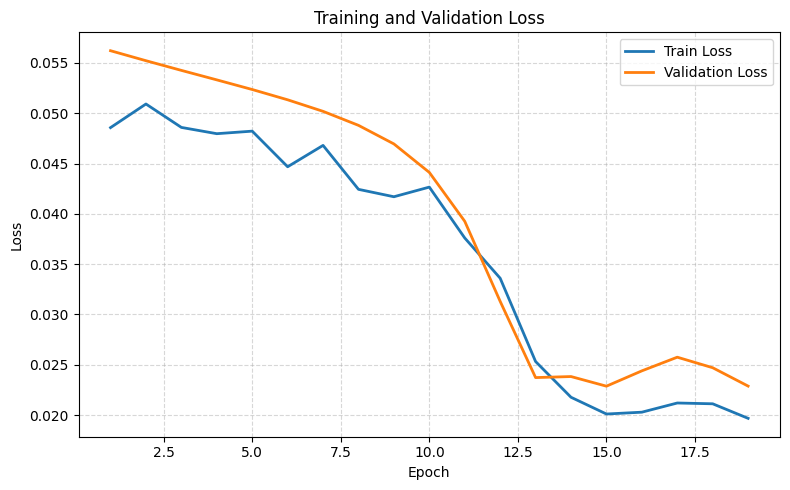

In [18]:
def plot_losses(train_losses, val_losses):
    plt.figure(figsize=(8, 5))

    epochs = range(1, len(train_losses) + 1)

    plt.plot(epochs, train_losses, label='Train Loss', linewidth=2)
    plt.plot(epochs, val_losses, label='Validation Loss', linewidth=2)

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_losses(train_losses, val_losses)

## 4-Evaluation

In [26]:
model.load_state_dict(torch.load("model/best_model.pth", map_location=device))
model.to(device)

IndustrialPoseNet(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU(inplace=True)
    (11): AdaptiveAvgPool2d(output_size=1)
  )
  (head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=64, out_features=4, bias=True)
    (4): Sigmoid()
  )
)

In [27]:
def evaluate(model, loader, criterion, device):

    model.eval()

    total_loss = 0.0
    total_distance = 0.0
    total_keypoints = 0

    with torch.no_grad():

        for images, targets in loader:

            images = images.to(device)
            keypoints = targets["keypoints"].to(device)
            gt = keypoints[:, :, :2]
            gt_flat = gt.reshape(gt.size(0), -1)


            pred_flat = model(images)


            loss = criterion(pred_flat, gt_flat)
            total_loss += loss.item()
            pred = pred_flat.view(gt.shape)

            dist = torch.norm(pred - gt, dim=2)

            total_distance += dist.sum().item()
            total_keypoints += dist.numel()

    avg_loss = total_loss / len(loader)
    avg_distance = total_distance / total_keypoints

    return avg_loss, avg_distance

avg_loss, avg_distance = evaluate(model=model, loader=test_loader, criterion=criterion, device=device)

In [25]:
result = pd.DataFrame([avg_loss, avg_distance], index=['Avg Loss', 'Avg Distance'], columns=['Score'])
result

,Score
Avg Loss,0.025616
Avg Distance,0.201311


tensor([[0.4451, 0.2210, 0.4644, 0.6890]], device='cuda:0')


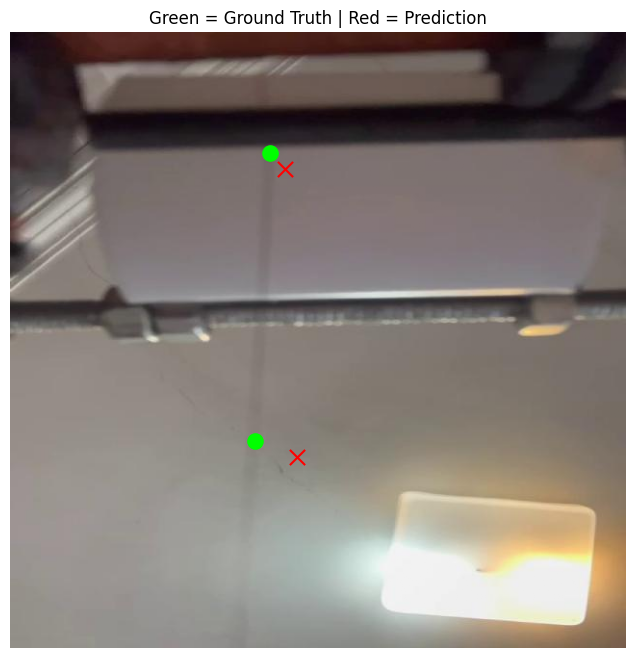

In [32]:
model.eval()
images, targets = next(iter(test_loader))

idx = 2
image = images[idx].to(device)

with torch.no_grad():
    pred = model(image.unsqueeze(0))
    print(pred)


pred = pred.squeeze(0).cpu().reshape(-1, 2)
gt = targets["keypoints"][idx][:, :2]


img = images[idx].permute(1, 2, 0).numpy()
H, W = img.shape[:2]

plt.figure(figsize=(8, 8))
plt.imshow(img)

# Draw ground truth (green)
for x, y in gt:
    plt.scatter(x * W, y * H, color='lime', s=120, marker='o')

# Draw prediction (red)
for x, y in pred:
    plt.scatter(x * W, y * H, color='red', s=120, marker='x')

plt.title("Green = Ground Truth | Red = Prediction")
plt.axis("off")
plt.show()